In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AvisEcommerce") \
    .getOrCreate()

spark

In [3]:
df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .option("multiLine", True) \
    .option("escape", '"') \
    .csv("Reviews.csv")

df.printSchema()

root
 |-- Id: integer (nullable = true)
 |-- ProductId: string (nullable = true)
 |-- UserId: string (nullable = true)
 |-- ProfileName: string (nullable = true)
 |-- HelpfulnessNumerator: integer (nullable = true)
 |-- HelpfulnessDenominator: integer (nullable = true)
 |-- Score: integer (nullable = true)
 |-- Time: integer (nullable = true)
 |-- Summary: string (nullable = true)
 |-- Text: string (nullable = true)



In [9]:
# On travaille sur un échantillon de 5% pour l'instant — beaucoup plus rapide
# On repassera sur le dataset complet une fois le pipeline validé
df_sample = df.sample(fraction=0.05, seed=42)
df_sample.count()

28408

In [11]:
# dropna(subset=[...]) : supprime les lignes où au moins une des colonnes
# listées est vide/nulle. On ne cible que les colonnes indispensables
# à l'analyse (pas besoin que ProfileName soit rempli, par exemple)
df_clean = df_sample.dropna(subset=["ProductId", "Score", "Text"])

# dropDuplicates() : supprime les lignes strictement identiques sur
# toutes les colonnes (doublons exacts)
df_clean = df_clean.dropDuplicates()

# try_cast (via F.expr) : tente de convertir Score en nombre décimal (float).
# Contrairement à .cast() classique, try_cast ne plante jamais :
# si une valeur est corrompue/mal parsée, elle devient simplement NULL
# au lieu de faire échouer tout le calcul
df_clean = df_clean.withColumn("Score", F.expr("try_cast(Score as float)"))

# On filtre : on ne garde que les notes réellement comprises entre 1 et 5.
# Ça élimine à la fois les valeurs aberrantes ET les NULL générés par try_cast
# juste au-dessus (NULL >= 1 est toujours faux en SQL/Spark, donc exclu automatiquement)
df_clean = df_clean.filter((F.col("Score") >= 1) & (F.col("Score") <= 5))

# cache() : dit à Spark de garder ce DataFrame en mémoire après le premier calcul,
# au lieu de tout recalculer depuis le CSV à chaque nouvelle action.
# Utile ici car on va faire plusieurs opérations différentes sur df_clean ensuite
df_clean = df_clean.cache()

print("Lignes après nettoyage :", df_clean.count())

NameError: name 'F' is not defined

In [12]:
# groupBy("ProductId") : regroupe toutes les lignes ayant le même ProductId.
# Ça ne calcule rien en soi, ça définit juste "comment découper en groupes"
stats_produits = df_clean.groupBy("ProductId").agg(
    
    # Pour chaque groupe (= chaque produit), calcule la moyenne des Score,
    # puis arrondit à 2 décimales pour un affichage plus lisible
    F.round(F.avg("Score"), 2).alias("note_moyenne"),
    
    # count("*") compte simplement le nombre de lignes dans chaque groupe,
    # donc ici le nombre d'avis reçus par ce produit
    F.count("*").alias("nombre_avis")
)

# Trie les produits par nombre d'avis décroissant (les plus commentés en premier)
stats_produits = stats_produits.orderBy(F.desc("nombre_avis"))

# show(10) : action qui déclenche le calcul réel et affiche les 10 premières lignes
stats_produits.show(10)

NameError: name 'F' is not defined

In [7]:
# On fixe un seuil minimum d'avis avant d'être éligible au classement.
# Sans ce seuil, un produit avec 1 seul avis à 5 étoiles battrait injustement
# un produit avec 500 avis à 4.8 — c'est un biais statistique classique
# (la moyenne sur un petit échantillon n'est pas fiable)
SEUIL_MIN_AVIS = 5  # abaissé à 5 ici car on travaille sur un échantillon réduit ;
                     # remettre à 10+ quand on repassera sur le dataset complet

top_produits = stats_produits.filter(F.col("nombre_avis") >= SEUIL_MIN_AVIS)

# Tri par note moyenne décroissante ; en cas d'égalité de note,
# on départage par nombre d'avis décroissant (le plus "confirmé" gagne)
top_produits = top_produits.orderBy(
    F.desc("note_moyenne"),
    F.desc("nombre_avis")
)

# On ne garde que les 20 premiers résultats
top_produits = top_produits.limit(20)

top_produits.show(20)

NameError: name 'stats_produits' is not defined

In [33]:
# from_unixtime(Time) : convertit le nombre de secondes en date/heure lisible
# (format string 'yyyy-MM-dd HH:mm:ss')
# date_format(..., "yyyy-MM") : ne garde que l'année et le mois,
# pour regrouper les avis par mois plutôt que par jour exact
df_clean = df_clean.withColumn(
    "annee_mois",
    F.date_format(F.from_unixtime(F.col("Time")), "yyyy-MM")
)

# Vérifions que la conversion a bien fonctionné avant d'agréger
df_clean.select("Time", "annee_mois").show(5)

+----------+----------+
|      Time|annee_mois|
+----------+----------+
|1324339200|   2011-12|
|1322179200|   2011-11|
|1339372800|   2012-06|
|1266969600|   2010-02|
|1330300800|   2012-02|
+----------+----------+
only showing top 5 rows


In [20]:
# groupBy("annee_mois") : regroupe tous les avis du même mois ensemble
evolution_avis = df_clean.groupBy("annee_mois").agg(
    F.count("*").alias("nombre_avis")
)

# orderBy("annee_mois") : tri chronologique (et non pas par nombre d'avis,
# cette fois on veut voir l'évolution dans le temps, donc l'ordre des dates compte)
evolution_avis = evolution_avis.orderBy("annee_mois")

evolution_avis.show(30)

NameError: name 'F' is not defined

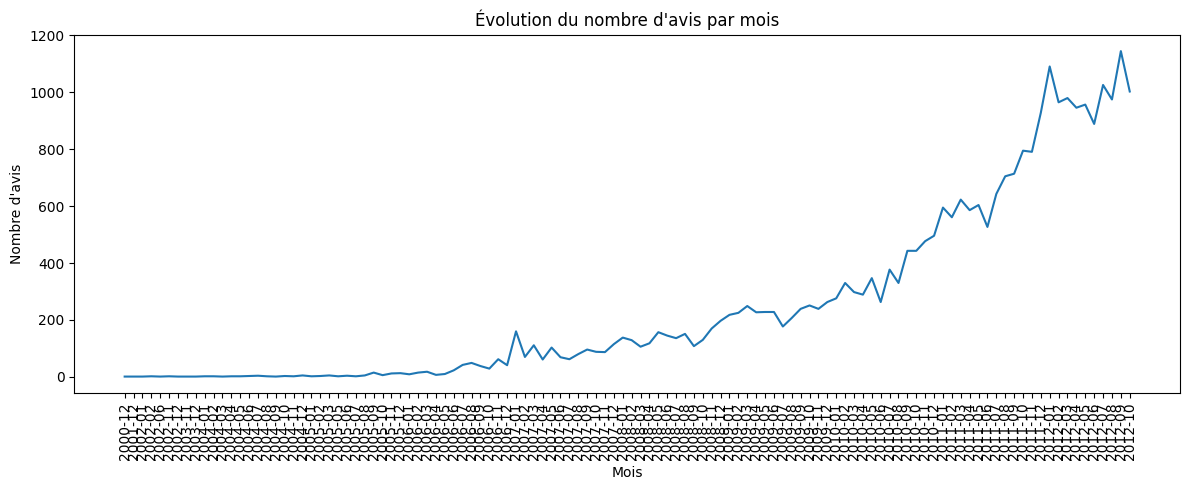

In [35]:
import matplotlib.pyplot as plt

# toPandas() : convertit un DataFrame Spark (potentiellement énorme) en DataFrame pandas.
# ATTENTION : on ne fait ça QUE parce que evolution_avis est déjà un résultat agrégé,
# donc petit. Ne jamais faire .toPandas() sur un DataFrame Spark brut/volumineux :
# ça chargerait tout en mémoire locale et ferait planter le programme
pdf = evolution_avis.toPandas()

plt.figure(figsize=(12, 5))
plt.plot(pdf["annee_mois"], pdf["nombre_avis"])
plt.xticks(rotation=90)
plt.title("Évolution du nombre d'avis par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre d'avis")
plt.tight_layout()
plt.show()

In [17]:
# getNumPartitions() : indique en combien de morceaux le DataFrame est actuellement découpé
print("Nombre de partitions :", df.rdd.getNumPartitions())

Nombre de partitions : 1


In [18]:
# repartition(4) : redécoupe explicitement le DataFrame en 4 partitions.
# Sur une machine avec peu de cœurs (typique d'un PC portable), un nombre
# trop élevé de partitions crée plus de overhead que de bénéfice.
# 4 est un bon point de départ pour du développement local.
df_full_clean = df.dropna(subset=["ProductId", "Score", "Text"]) \
    .dropDuplicates() \
    .withColumn("Score", F.expr("try_cast(Score as float)")) \
    .filter((F.col("Score") >= 1) & (F.col("Score") <= 5)) \
    .repartition(4) \
    .cache()

# On teste avec juste .count() d'abord, PAS .show() sur une agrégation complète tout de suite
# count() est l'action la plus simple, ça nous dit si le pipeline tient la charge
# avant de tenter quelque chose de plus lourd
print("Lignes après nettoyage complet :", df_full_clean.count())

NameError: name 'F' is not defined

In [19]:
SEUIL_MIN_AVIS = 10

top_produits = stats_produits.filter(F.col("nombre_avis") >= SEUIL_MIN_AVIS) \
    .orderBy(F.desc("note_moyenne"), F.desc("nombre_avis")) \
    .limit(20)

top_produits.show(20)

NameError: name 'stats_produits' is not defined

In [40]:
df_full_clean = df_full_clean.withColumn(
    "annee_mois",
    F.date_format(F.from_unixtime(F.col("Time")), "yyyy-MM")
)

evolution_avis = df_full_clean.groupBy("annee_mois").agg(
    F.count("*").alias("nombre_avis")
).orderBy("annee_mois")

evolution_avis.show(30)

+----------+-----------+
|annee_mois|nombre_avis|
+----------+-----------+
|   1999-10|          2|
|   1999-12|          4|
|   2000-01|          8|
|   2000-02|          3|
|   2000-06|          5|
|   2000-07|          1|
|   2000-08|          5|
|   2000-10|          3|
|   2000-12|          7|
|   2001-02|          1|
|   2001-05|          1|
|   2001-06|          1|
|   2001-08|          3|
|   2001-09|          3|
|   2001-10|          3|
|   2001-12|          1|
|   2002-01|          3|
|   2002-02|         15|
|   2002-03|          6|
|   2002-04|          1|
|   2002-05|          2|
|   2002-06|          9|
|   2002-07|          4|
|   2002-08|          1|
|   2002-09|          1|
|   2002-10|          4|
|   2002-11|         21|
|   2002-12|          6|
|   2003-01|          4|
|   2003-02|          3|
+----------+-----------+
only showing top 30 rows


In [1]:
# orderBy avec desc() : trie cette fois du mois le plus récent au plus ancien,
# pour voir le pic d'activité en fin de période plutôt que les débuts
evolution_avis.orderBy(F.desc("annee_mois")).show(10)

NameError: name 'evolution_avis' is not defined

In [41]:
from pymongo import MongoClient

# MongoClient : point d'entrée vers le serveur MongoDB, similaire à SparkSession pour Spark
client = MongoClient("mongodb://localhost:27017/")

# On crée/accède à une base nommée "avis_ecommerce" (créée automatiquement
# dès qu'on y écrit quelque chose, pas besoin de la déclarer à l'avance —
# différence notable avec SQL où CREATE DATABASE est obligatoire)
db = client["avis_ecommerce"]

# Test simple : lister les bases de données existantes sur le serveur
print(client.list_database_names())

['admin', 'config', 'local']


In [42]:
# On récupère juste les ProductId qui sont dans le top 20, sous forme d'ensemble Python
# .collect() : ramène les résultats du cluster Spark vers Python (à utiliser
# uniquement sur de PETITS résultats déjà agrégés, jamais sur les données brutes)
top_ids = set(row["ProductId"] for row in top_produits.select("ProductId").collect())

print("Nombre de top produits :", len(top_ids))

Nombre de top produits : 20


In [43]:
# toPandas() : convertit le DataFrame Spark en DataFrame pandas
# (encore une fois, OK ici car stats_produits est un résultat agrégé, pas les données brutes)
pdf_stats = stats_produits.toPandas()

# On construit la liste des documents à insérer, un dict Python = un document JSON MongoDB
documents = []
for _, row in pdf_stats.iterrows():
    documents.append({
        "_id": row["ProductId"],              # _id : identifiant unique MongoDB natif, on réutilise ProductId
        "note_moyenne": float(row["note_moyenne"]),
        "nombre_avis": int(row["nombre_avis"]),
        "est_top_produit": row["ProductId"] in top_ids  # enrichissement : booléen calculé à partir du set créé plus haut
    })

print("Nombre de documents à insérer :", len(documents))
print(documents[0])  # aperçu du premier document

Nombre de documents à insérer : 74258
{'_id': 'B007JFMH8M', 'note_moyenne': 4.58, 'nombre_avis': 913, 'est_top_produit': False}


In [44]:
# On accède (ou crée si elle n'existe pas encore) une collection nommée "stats_produits"
# Une collection MongoDB = l'équivalent d'une table SQL, mais sans schéma fixe imposé
collection = db["stats_produits"]

# drop() : on vide la collection avant d'insérer, pour éviter les doublons
# si vous relancez cette cellule plusieurs fois pendant les tests
collection.drop()

# insert_many() : insère toute la liste de documents en une seule opération,
# beaucoup plus efficace qu'une boucle avec insert_one() répété
resultat = collection.insert_many(documents)

print(f"{len(resultat.inserted_ids)} documents insérés dans la collection 'stats_produits'")

74258 documents insérés dans la collection 'stats_produits'


In [45]:
# count_documents({}) : compte tous les documents de la collection
# ({} = filtre vide = "tous les documents", syntaxe MongoDB standard)
print("Nombre de documents dans la collection :", collection.count_documents({}))

# find_one() : récupère un document au hasard pour vérifier son contenu
print(collection.find_one())

Nombre de documents dans la collection : 74258
{'_id': 'B007JFMH8M', 'note_moyenne': 4.58, 'nombre_avis': 913, 'est_top_produit': False}


In [46]:
pdf_evolution = evolution_avis.toPandas()

documents_evolution = []
for _, row in pdf_evolution.iterrows():
    documents_evolution.append({
        "annee_mois": row["annee_mois"],
        "nombre_avis": int(row["nombre_avis"])
    })

collection_evolution = db["evolution_avis"]
collection_evolution.drop()
resultat_evo = collection_evolution.insert_many(documents_evolution)

print(f"{len(resultat_evo.inserted_ids)} documents insérés dans 'evolution_avis'")

143 documents insérés dans 'evolution_avis'


In [47]:
df_full_clean.count()

568454

In [22]:
# 1. Valeurs manquantes
df_clean = df.dropna(subset=["ProductId", "Score", "Text"])
df_clean.count()

568454

In [23]:
df_clean = df_clean.dropDuplicates()
df_clean.count()

568454

In [24]:
df_clean = df.dropna(subset=["ProductId", "Score", "Text"])
df_clean = df_clean.dropDuplicates()
df_clean = df_clean.withColumn("Score", F.expr("try_cast(Score as float)"))
df_clean.filter(F.col("Score").isNull()).count()

0

In [25]:
from pyspark.sql import functions as F

df_clean = df_clean.withColumn("Score", F.col("Score").cast("float"))
df_clean = df_clean.filter((F.col("Score") >= 1) & (F.col("Score") <= 5))
df_clean.count()

568454

In [26]:
total_avant = df.count()
total_apres = df_clean.count()
print(f"Avant nettoyage : {total_avant} lignes")
print(f"Après nettoyage : {total_apres} lignes")
print(f"Lignes supprimées : {total_avant - total_apres} ({100*(total_avant-total_apres)/total_avant:.2f}%)")

Avant nettoyage : 568454 lignes
Après nettoyage : 568454 lignes
Lignes supprimées : 0 (0.00%)


In [27]:
df_clean = df_clean.filter((F.col("Score") >= 1) & (F.col("Score") <= 5))
df_clean.count()

568454

In [28]:
# groupBy(...) : on regroupe toutes les lignes ayant le même ProductId ensemble
# C'est l'équivalent Spark du "GROUP BY" en SQL
stats_produits = df_clean.groupBy("ProductId").agg(
    # avg("Score") : calcule la moyenne des notes pour chaque groupe
    # round(..., 2) : arrondit à 2 décimales pour un affichage propre
    F.round(F.avg("Score"), 2).alias("note_moyenne"),
    
    # count("*") : compte le nombre de lignes (= nombre d'avis) par groupe
    F.count("*").alias("nombre_avis")
)

# orderBy avec desc() : trie par nombre d'avis décroissant
# Utile pour voir tout de suite les produits les plus commentés
stats_produits = stats_produits.orderBy(F.desc("nombre_avis"))

# show() déclenche le calcul réel (action) et affiche un aperçu
stats_produits.show(10)

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\py4j\java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\py4j\clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
# On fixe un seuil minimum d'avis : sans ça, un produit avec 1 seul avis
# à 5 étoiles surclasserait injustement un produit avec 500 avis à 4.8
SEUIL_MIN_AVIS = 10

top_produits = stats_produits.filter(
    F.col("nombre_avis") >= SEUIL_MIN_AVIS
)

# Tri par note moyenne décroissante, puis par nombre d'avis en cas d'égalité
top_produits = top_produits.orderBy(
    F.desc("note_moyenne"), 
    F.desc("nombre_avis")
)

# limit(20) : ne garde que les 20 premiers résultats
top_produits = top_produits.limit(20)

top_produits.show(20)

In [ ]:
print("df brut :", df.count())
print("df_clean :", df_clean.count())

In [ ]:
print("test")